In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from transformers import AutoModelForQuestionAnswering, AutoTokenizer
import torch

In [3]:
import os
import sys
module_path = os.path.join(os.getcwd(), '..')
sys.path.append(module_path)

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model_name = "MrKite/bert-large-squadv2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForQuestionAnswering.from_pretrained(model_name).to(device=device, dtype=torch.bfloat16)

In [5]:
model

BertForQuestionAnswering(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 1024, padding_idx=0)
      (position_embeddings): Embedding(512, 1024)
      (token_type_embeddings): Embedding(2, 1024)
      (LayerNorm): LayerNorm((1024,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-23): 24 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=1024, out_features=1024, bias=True)
              (key): Linear(in_features=1024, out_features=1024, bias=True)
              (value): Linear(in_features=1024, out_features=1024, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=1024, out_features=1024, bias=True)
              (LayerNorm): LayerNorm((1024,)

In [6]:
from lrp_engine import LRPEngine, checkpoint_hook
from lrp_engine.lrp_graph import make_graph

In [7]:
lrp = LRPEngine(topk=1, use_gamma=True, dtype=torch.bfloat16)

In [8]:
from datasets import load_dataset

dataset = load_dataset("squad_v2")

In [12]:
### Figure out the tokenizer specifics here

context = "Welcome to the final examination for this term's offering of CS100. Please remove all headphones and earbuds, as well as hats and hoods. Place your bag under your desk so that it does not block the aisle. You are permitted writing instruments, a clear water bottle, and any aids listed on the front of your booklet. The exam will be 150 minutes in duration. You may now begin."
question = "How long is the exam?"

input_ids = tokenizer(question, context, return_tensors="pt")["input_ids"]

# output = model(input_ids.to(device))

# start = torch.argmax(output.start_logits)
# end = torch.argmax(output.end_logits) + 1

# answer_tokens = input_ids[0][start:end]
# answer = tokenizer.decode(answer_tokens, skip_special_tokens=True)
# print(answer)

In [14]:
tokenizer(question, return_tensors="pt")["input_ids"]

tensor([[  101,  2129,  2146,  2003,  1996, 11360,  1029,   102]])

In [21]:
tokenizer.sep_token_id

102

In [13]:
input_ids

tensor([[  101,  2129,  2146,  2003,  1996, 11360,  1029,   102,  6160,  2000,
          1996,  2345,  7749,  2005,  2023,  2744,  1005,  1055,  5378,  1997,
         20116, 18613,  1012,  3531,  6366,  2035,  2132, 19093,  1998,  4540,
          8569,  5104,  1010,  2004,  2092,  2004, 16717,  1998,  7415,  2015,
          1012,  2173,  2115,  4524,  2104,  2115,  4624,  2061,  2008,  2009,
          2515,  2025,  3796,  1996, 12485,  1012,  2017,  2024,  7936,  3015,
          5693,  1010,  1037,  3154,  2300,  5835,  1010,  1998,  2151,  8387,
          3205,  2006,  1996,  2392,  1997,  2115, 19271,  1012,  1996, 11360,
          2097,  2022,  5018,  2781,  1999,  9367,  1012,  2017,  2089,  2085,
          4088,  1012,   102]])

In [11]:
start = torch.argmax(output.start_logits)
end = torch.argmax(output.end_logits) + 1

answer_tokens = input_ids[0][start:end]
answer = tokenizer.decode(answer_tokens, skip_special_tokens=True)
print(answer)

150 minutes


In [12]:
lrp_output = lrp.run((output.start_logits, output.end_logits))

In [33]:
lrp_output = lrp.run(output.last_hidden_state)

In [13]:
lrp_output

([],
 [tensor([[1.8120e-04, 1.0910e-03, 1.3580e-03, 2.8610e-04, 1.5831e-04, 1.1978e-03,
           4.0245e-04, 3.9291e-04, 7.8964e-04, 8.7738e-05, 1.0681e-04, 2.6894e-04,
           6.4087e-04, 9.9182e-05, 1.1301e-04, 3.5667e-04, 9.1076e-05, 8.5354e-05,
           2.4414e-04, 6.8665e-05, 2.5177e-04, 4.2915e-04, 1.8692e-04, 4.0627e-04,
           2.9373e-04, 1.0347e-04, 1.0538e-04, 3.2997e-04, 5.2691e-05, 1.6880e-04,
           8.7261e-05, 6.2943e-05, 6.8188e-05, 4.6492e-05, 8.2016e-05, 4.5538e-05,
           1.7834e-04, 5.3644e-05, 1.5450e-04, 5.7459e-05, 1.7357e-04, 1.5736e-04,
           1.7071e-04, 2.2125e-04, 9.7275e-05, 1.1730e-04, 2.9373e-04, 8.8692e-05,
           4.9114e-05, 5.4121e-05, 7.7724e-05, 7.1526e-05, 1.0777e-04, 8.1539e-05,
           3.7193e-04, 1.8024e-04, 2.0123e-04, 1.4782e-04, 3.7956e-04, 3.0518e-04,
           3.5095e-04, 9.5844e-05, 7.8678e-05, 1.5354e-04, 1.7357e-04, 2.3651e-04,
           9.5367e-05, 7.7724e-05, 1.7738e-04, 4.8447e-04, 3.6430e-04, 1.0967e-04,

In [37]:
pos_inds = torch.where((2 * lrp_output[1][0] / lrp_output[1][0].max() - 1).cpu() > 0)

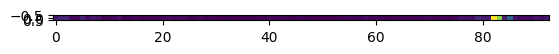

In [16]:
from matplotlib import pyplot as plt

plt.imshow(lrp_output[1][0].cpu().float())

In [38]:
# print(lrp_output[1][0].topk(10))

tokenizer.convert_ids_to_tokens(input_ids[pos_inds])

['150', 'minutes']

In [37]:
g = make_graph(output.last_hidden_state)
g[2], len(g[2]), g[4]

({'MulBackward0': 366,
  'AccumulateGrad': 310,
  'ToCopyBackward0': 226,
  'AddBackward0': 225,
  'EmbeddingBackward0': 1,
  'UnsafeViewBackward0': 252,
  'MmBackward0': 196,
  'ViewBackward0': 308,
  'TransposeBackward0': 112,
  'ScaledDotProductEfficientAttentionBackward0': 28,
  'CloneBackward0': 84,
  'RsqrtBackward0': 113,
  'MeanBackward1': 113,
  'PowBackward0': 113,
  'TBackward0': 196,
  'CatBackward0': 56,
  'NegBackward0': 56,
  'SliceBackward0': 336,
  'ExpandBackward0': 56,
  'UnsqueezeBackward0': 56,
  'SiluBackward0': 28},
 21,
 3231)

In [ ]:
# QA version

from tqdm import tqdm
import json
import pickle

def run_roberta_squad_benchmark(model, tokenizer, lrp, dataset, run_name, question_first=True, model_topk=2):
    results = []
    top1_label_hits = 0
    top1_model_hits = 0
    total_examples = 0
    total_strict_intersect = 0
    total_span_intersect = 0
    total_strict_union = 0
    total_span_union = 0
    total_strict_iou = 0
    total_span_iou = 0
    model_exact_matches = 0
    lrp_model_exact_matches = 0
    precision_denom = 0
    recall_denom = 0
    total_overlap = 0
    total_overlap_ratio = 0
    total_start_end_skips = 0
    total_empty_answer_skips = 0
    total_unanswerable = 0
    lrp_label_exact_matches = 0
    total_strict_label_intersect = 0
    total_strict_label_union = 0
    total_span_label_intersect = 0
    total_span_label_union = 0
    total_span_label_union = 0
    total_strict_label_iou = 0
    total_span_label_iou = 0
    for example in tqdm(dataset["validation"]):
        question = example["question"]
        context = example["context"]
        answers = example["answers"]["text"]
        answer_start_inds = example["answers"]["answer_start"]
    
        if not answers:
            total_unanswerable += 1
            continue
    
        answer_char_ranges = [ (i, i + len(a)) for (a, i) in zip(answers, answer_start_inds) ]
    
        if question_first:
            tokenized = tokenizer(question, context, return_tensors="pt", return_offsets_mapping=True)
            input_ids = tokenized["input_ids"].to(device)
            offset_mapping = tokenized["offset_mapping"]
        else:
            tokenized = tokenizer(context, question, return_tensors="pt", return_offsets_mapping=True)
            input_ids = tokenized["input_ids"].to(device)
            offset_mapping = tokenized["offset_mapping"]
        if input_ids.shape[-1] > 512:
            continue
    
        output = model(input_ids.to(device))
    
        # Tokenizer outputs [CLS]<question>[SEP]<context>[SEP]
        # We need to mask the question tokens in the start/end logits, this is standard in QA evals
        sep_token_ind = list(input_ids[0]).index(tokenizer.sep_token_id)
        mask = torch.zeros_like(output.start_logits).bool()
        if question_first:
            mask_slice = [slice(None, None), slice(sep_token_ind + 1, None)]
        else:
            mask_slice = [slice(None, None), slice(None, sep_token_ind + 1)]
        mask[mask_slice] = True
    
        masked_start_logits = output.start_logits.masked_fill(~mask, -float("inf"))
        masked_end_logits = output.end_logits.masked_fill(~mask, -float("inf"))
        start = torch.argmax(masked_start_logits)
        end = torch.argmax(masked_end_logits)
    
        if start > end:
            total_start_end_skips += 1
            continue

        # Get the decoded answer per the model
        model_answer = tokenizer.decode(input_ids[0][start:end + 1], skip_special_tokens=False).replace("<unk>", "x").strip()
        if model_answer == "":
            total_empty_answer_skips += 1
            continue
    
        # Convert from token inds to char inds since that's how the dataset tracks the labels
        char_start = offset_mapping[0][start][0]
        if context[char_start] == " ":
            char_start += 1
        char_end = offset_mapping[0][end][1]

        # Take the answer where the prediction gets the best # chars intersecting over the model and label ranges divided by total # chars in label
        # best_overlap_ratio is the Jaccard similarity
        best_overlap, best_answer_len, best_overlap_ratio = max([ (ans_overlap := (max(0, min(char_end, answer_end) - max(char_start, answer_start))), ans_len := (answer_end - answer_start), ans_overlap / (ans_len + len(model_answer) - ans_overlap)) for (answer_start, answer_end) in answer_char_ranges ], key =lambda x: x[2])
        total_overlap += best_overlap
        total_overlap_ratio += best_overlap_ratio
        precision_denom += len(model_answer)
        recall_denom += best_answer_len
    
        if model_exact_match := (best_overlap_ratio == 1):
            model_exact_matches += 1

        # Now run LRP
        lrp_input1, lrp_input2 = output.start_logits, output.end_logits
        lrp_input1[0][0] = 0
        lrp_input2[0][0] = 0
        checkpoint_vals, param_vals = lrp.run((lrp_input1, lrp_input2))

        lrp_max = param_vals[2].masked_fill(~mask, -float("inf")).flatten().argmax()
        lrp_top_token = tokenizer.decode([input_ids[0][lrp_max]], skip_special_tokens=True).strip().replace(chr(9601), "")

        # Do model answer-based accuracy, i.e. is the attribution aligned with the model prediction
        if start <= lrp_max <= end:
            top1_model_hits += 1

        # Do IoU with the model prediction
        # We split into two ways to compute:
        # For Strict IoU we do not count tokens IN BETWEEN start and end because the model is meant to only output 2 signals for start and end.
        # So, strict_intersect = 2, strict_union = 2 if LRP top-2 and the model prediction indices matched exactly
        # strict_intersect = 1, strict_union = 3 if LRP only 1 of the LRP top-2 was a model prediction index
        # strict_intersect = 0, strict_union = 4 if neither LRP top-2 were a model prediction index
        # We double count in the case of single word answers (start = end), and do not consider the second place attributed token if the first
        #   place token was the answer.
        # For Span IoU, we DO count tokens in between start and end
        strict_intersect = 0
        span_intersect = 0
        strict_union = model_topk
        span_union = model_topk
        found_start = False
        found_end = False
        for top_ind in param_vals[2].flatten().topk(model_topk).indices:
            if found_start and found_end:
                break
            if start == top_ind:
                found_start = True
                strict_intersect += 1
                span_intersect += 1

            if end == top_ind:   # Crucial to keep these two as separate ifs for single-word answers
                found_end = True
                strict_intersect += 1
                span_intersect += 1

            if start < top_ind < end:
                strict_union += 1
                span_intersect += 1

            elif top_ind < start or end < top_ind:
                strict_union += 1
                span_union += 1

        if lrp_model_exact_match := (strict_intersect == strict_union):
            lrp_model_exact_matches += 1
        total_strict_intersect += strict_intersect
        total_strict_union += strict_union
        total_span_intersect += span_intersect
        total_span_union += span_union
        total_strict_iou += strict_intersect / strict_union
        total_span_iou += span_intersect / span_union

        # LRP-Label IoU using normalized relevance and positive filtering, like what we assume happens in the AttnLRP paper
        # Also described in AttnLRP paper, we only do this for the model-label exact matches
        strict_label_intersect = None
        span_label_intersect = None
        strict_label_union = None
        span_label_union = None
        lrp_label_exact_match = None
        if model_exact_match:
            pos_inds = torch.where((2 * param_vals[2].flatten() / param_vals[2].flatten().max() - 1).cpu() > 0)[0]
            strict_label_intersect = 0
            span_label_intersect = 0
            strict_label_union = 2
            span_label_union = int(end - start + 1)
            for top_ind in pos_inds:
                if found_start and found_end:
                    break
                if start == top_ind or end == top_ind:
                    span_label_intersect += 1
                    strict_label_intersect += 1
                    if start == top_ind and end == top_ind:
                        strict_label_intersect += 1
    
                if start < top_ind < end:
                    strict_label_union += 1
                    span_label_intersect += 1

                elif top_ind < start or end < top_ind:
                    strict_label_union += 1
                    span_label_union += 1

            if strict_label_intersect / strict_label_union > 1 or span_label_intersect / span_label_union > 1:
                print("ERROR ", strict_label_intersect, strict_label_union, span_label_intersect, span_label_union)
    
            if lrp_label_exact_match := (strict_label_intersect == strict_label_union):
                lrp_label_exact_matches += 1
            total_strict_label_intersect += strict_label_intersect
            total_strict_label_union += strict_label_union
            total_span_label_intersect += span_label_intersect
            total_span_label_union += span_label_union
            total_strict_label_iou += strict_label_intersect / strict_label_union
            total_span_label_iou += span_label_intersect / span_label_union

        # Do label-based accuracy
        if any(lrp_top_token in ans for ans in answers):
            # Is the attribution aligned with the ground truth label
            top1_label_hits += 1

        lrp_top5 = param_vals[2].flatten().topk(k=5)
        lrp_top5_tokens = tokenizer.decode(input_ids[0][lrp_top5.indices.cpu()])
        results.append({
            "example": example,
            "model_exact_match": bool(model_exact_match),
            "lrp_top1_ind": lrp_max.tolist(),
            "model_start_end": (start.detach().cpu().tolist(), end.detach().cpu().tolist()),
            "lrp_top1_token": lrp_top_token,
            "lrp_top5_tokens": lrp_top5_tokens,
            "lrp_top5_relevances": lrp_top5.values.detach().cpu().tolist(),
            "lrp_model_strict_intersect": strict_intersect,
            "lrp_model_strict_union": strict_union,
            "lrp_model_span_intersect": span_intersect,
            "lrp_model_span_union": span_union,
            "lrp_model_exact_match": lrp_model_exact_match,
            "lrp_label_strict_intersect": strict_label_intersect,
            "lrp_label_strict_union": strict_label_union,
            "lrp_label_span_intersect": span_label_intersect,
            "lrp_label_span_union": span_label_union,
            "lrp_label_exact_match": lrp_label_exact_match,
        })

        total_examples += 1
        if not (total_examples % 100):
            precision = float(total_overlap / precision_denom)
            recall = float(total_overlap / recall_denom)
            f1 = float(2 / ((1 / precision) + (1 / recall)))
            print("Total examples: ", total_examples)
            print("Model exact matches: ", model_exact_matches)
            print("Model exact match %: ", model_exact_matches / total_examples)
            print("Model precision: ", precision)
            print("Model recall: ", recall)
            print("Model F1: ", f1)
            print("Model overlap ratio: ", float(total_overlap_ratio / total_examples))
            print("LRP Top-1 model answer hits: ", top1_model_hits)
            print("LRP Top-1 model answer hit %: ", top1_model_hits / total_examples)
            print("LRP Top-1 label answer hits: ", top1_label_hits)
            print("LRP Top-1 label answer hit %: ", top1_label_hits / total_examples)
            print(f"LRP Top-{model_topk} Strict Accuracy: ", total_strict_intersect / (model_topk * total_examples))
            print(f"LRP Top-{model_topk} Span Accuracy: ", total_span_intersect / (model_topk * total_examples))
            print("LRP-Model exact matches: ", lrp_model_exact_matches)
            print("LRP-Model Strict IoU: ", total_strict_intersect / total_strict_union)
            print("LRP-Model Span IoU: ", total_span_intersect / total_span_union)
            print("LRP-Model Avg Strict IoU: ", total_strict_iou / total_examples)
            print("LRP-Model Avg Span IoU: ", total_span_iou / total_examples)
            print("LRP-Label exact matches: ", lrp_label_exact_matches)
            print("LRP-Label Strict IoU: ", total_strict_label_intersect / total_strict_label_union)
            print("LRP-Label Span IoU: ", total_span_label_intersect / total_span_label_union)
            print("LRP-Label Avg Strict IoU: ", total_strict_label_iou / model_exact_matches)
            print("LRP-Label Avg Span IoU: ", total_span_label_iou / model_exact_matches)
            print("Total start-end skips: ", total_start_end_skips)
            print("Total empty model answer skips: ", total_empty_answer_skips)
            print("Total unanswerable: ", total_unanswerable)

    precision = float(total_overlap / precision_denom)
    recall = float(total_overlap / recall_denom)
    f1 = float(2 / ((1 / precision) + (1 / recall)))
    data = {
        "summary": {
            "total_examples": total_examples,
            "model_exact_matches": model_exact_matches,
            "model_exact_match_pct": model_exact_matches / total_examples,
            "model_precision": precision,
            "model_recall": recall,
            "model_f1": f1,
            "model_overlap_ratio": float(total_overlap_ratio / total_examples),
            "lrp_top1_model_answer_hits": top1_model_hits,
            "lrp_top1_model_answer_hit_pct": top1_model_hits / total_examples,
            "lrp_top1_label_answer_hits": top1_label_hits,
            "lrp_top1_label_answer_hit_pct": top1_label_hits / total_examples,
            f"lrp_top{model_topk}_strict_accuracy": total_strict_intersect / (model_topk * total_examples),
            f"lrp_top{model_topk}_span_accuracy": total_span_intersect / (model_topk * total_examples),
            "lrp_model_exact_matches": lrp_model_exact_matches,
            "lrp_model_strict_iou": total_strict_intersect / total_strict_union,
            "lrp_model_span_iou": total_span_intersect / total_span_union,
            "lrp_model_avg_strict_iou": total_strict_iou / total_examples,
            "lrp_model_avg_span_iou": total_span_iou / total_examples,
            "lrp_label_exact_matches": lrp_label_exact_matches,
            "lrp_label_strict_iou": total_strict_label_intersect / total_strict_label_union,
            "lrp_label_span_iou": total_span_label_intersect / total_span_label_union,
            "lrp_label_avg_strict_iou": total_strict_label_iou / model_exact_matches,
            "lrp_label_avg_span_iou": total_span_label_iou / model_exact_matches,
            "total_start_end_skips" : total_start_end_skips,
            "total_empty_answer_skips" : total_empty_answer_skips,
            "total_unanswerable" : total_unanswerable,
        },
        "results": results
    }

    try:
        with open(f"bert_squadv2_results_{run_name}.json", "w") as f:
            json.dump(data, f, indent=4)
    except TypeError:
        print("Failed JSON write, attempting pickle...")
        try:
            with open(f"roberta_squadv2_results_{run_name}.pkl", "wb") as f:
                pickle.dump(data, f)
        except Exception as e:
            print("Encountered exception while pickling, will return (data, exception)...")
            return data, e
    return data

In [12]:
results = run_roberta_squad_benchmark(model, tokenizer, lrp, dataset, "gamma")

  2%|█▍                                                                            | 217/11873 [00:27<18:58, 10.24it/s]

Total examples:  100
Model exact matches:  69
Model exact match %:  0.69
Model precision:  0.33042430877685547
Model recall:  0.8999999761581421
Model F1:  0.48338101525190713
Model overlap ratio:  0.7865696549415588
LRP Top-1 model answer hits:  89
LRP Top-1 model answer hit %:  0.89
LRP Top-1 label answer hits:  36
LRP Top-1 label answer hit %:  0.36
LRP Top-2 Strict Accuracy:  0.79
LRP Top-2 Span Accuracy:  0.82
LRP-Model exact matches:  71
LRP-Model Strict IoU:  0.6528925619834711
LRP-Model Span IoU:  0.6949152542372882
LRP-Model Avg Strict IoU:  0.7633333333333334
LRP-Model Avg Span IoU:  0.8033333333333335
LRP-Label exact matches:  0
LRP-Label Strict IoU:  0.0641025641025641
LRP-Label Span IoU:  0.051643192488262914
LRP-Label Avg Strict IoU:  0.05652173913043478
LRP-Label Avg Span IoU:  0.0427536231884058
Total start-end skips:  1
Total empty model answer skips:  0
Total unanswerable:  117


  4%|███                                                                           | 463/11873 [00:54<22:22,  8.50it/s]

Total examples:  200
Model exact matches:  116
Model exact match %:  0.58
Model precision:  0.40335071086883545
Model recall:  0.8555145859718323
Model F1:  0.5482277051824571
Model overlap ratio:  0.7320656776428223
LRP Top-1 model answer hits:  175
LRP Top-1 model answer hit %:  0.875
LRP Top-1 label answer hits:  108
LRP Top-1 label answer hit %:  0.54
LRP Top-2 Strict Accuracy:  0.7725
LRP Top-2 Span Accuracy:  0.815
LRP-Model exact matches:  137
LRP-Model Strict IoU:  0.6293279022403259
LRP-Model Span IoU:  0.6877637130801688
LRP-Model Avg Strict IoU:  0.7433333333333332
LRP-Model Avg Span IoU:  0.8000000000000002
LRP-Label exact matches:  0
LRP-Label Strict IoU:  0.0648854961832061
LRP-Label Span IoU:  0.055865921787709494
LRP-Label Avg Strict IoU:  0.059482758620689656
LRP-Label Avg Span IoU:  0.04482758620689655
Total start-end skips:  18
Total empty model answer skips:  0
Total unanswerable:  245


  6%|████▍                                                                         | 679/11873 [01:22<35:35,  5.24it/s]

Total examples:  300
Model exact matches:  156
Model exact match %:  0.52
Model precision:  0.4002853333950043
Model recall:  0.8195284605026245
Model F1:  0.537861146807983
Model overlap ratio:  0.6892086267471313
LRP Top-1 model answer hits:  258
LRP Top-1 model answer hit %:  0.86
LRP Top-1 label answer hits:  161
LRP Top-1 label answer hit %:  0.5366666666666666
LRP Top-2 Strict Accuracy:  0.755
LRP Top-2 Span Accuracy:  0.8033333333333333
LRP-Model exact matches:  201
LRP-Model Strict IoU:  0.606425702811245
LRP-Model Span IoU:  0.6713091922005571
LRP-Model Avg Strict IoU:  0.726666666666667
LRP-Model Avg Span IoU:  0.7900000000000003
LRP-Label exact matches:  0
LRP-Label Strict IoU:  0.05982905982905983
LRP-Label Span IoU:  0.05165289256198347
LRP-Label Avg Strict IoU:  0.05544871794871795
LRP-Label Avg Span IoU:  0.03804945054945056
Total start-end skips:  26
Total empty model answer skips:  0
Total unanswerable:  353


  7%|█████▌                                                                        | 852/11873 [01:46<23:03,  7.96it/s]


KeyboardInterrupt: 